# K-Nearest Neighbors (KNN) Classification Model

## Load data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [3]:
DATA_DIR = Path("data")

In [4]:
for file in DATA_DIR.glob("(experiment)*.csv"):
    print(file)

data/(experiment) y_train.csv
data/(experiment) X_train.csv
data/(experiment) y_test.csv
data/(experiment) X_test.csv


In [5]:
X_train = pd.read_csv(
    DATA_DIR / "(experiment) X_train.csv",
    index_col=0,
    parse_dates=True
)

y_train = pd.read_csv(
    DATA_DIR / "(experiment) y_train.csv",
    index_col=0,
    parse_dates=True
)

X_test = pd.read_csv(
    DATA_DIR / "(experiment) X_test.csv",
    index_col=0,
    parse_dates=True
)

y_test = pd.read_csv(
    DATA_DIR / "(experiment) y_test.csv",
    index_col=0,
    parse_dates=True
)

In [6]:
print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

TRAIN / TEST SPLIT
Training observations: 59
Testing observations: 18

Training period:
2007-06-30 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-03-31 00:00:00 to 2026-06-30 00:00:00

Training class distribution:
PCE_Regime
0             29
1             30
Name: count, dtype: int64

Testing class distribution:
PCE_Regime
0              8
1             10
Name: count, dtype: int64


# Step 1. Build the KNN pipeline

In [7]:
# ============================================================
# KNN CLASSIFICATION MODEL
# PCE Growth Regime Classification
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Build KNN pipeline
knn_pipeline = Pipeline([
    
    # Fill missing values using TRAINING medians
    ("imputer", SimpleImputer(strategy="median")),
    
    # KNN requires standardized features
    ("scaler", StandardScaler()),
    
    # Initial KNN model
    ("knn", KNeighborsClassifier(
        n_neighbors=5
    ))
])

print(knn_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


# Step 2. Train the KNN model 

In [8]:
# ============================================================
# TRAIN KNN
# ============================================================

knn_pipeline.fit(X_train,y_train)


/usr/local/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

# Step 3. Generate predictions

In [10]:
# ============================================================
# TEST PREDICTIONS
# ============================================================

knn_pred = knn_pipeline.predict(X_test)

knn_prob = knn_pipeline.predict_proba(X_test)[:, 1]


knn_predictions = pd.DataFrame({
    "Actual": y_test.squeeze(),
    "Predicted": knn_pred,
    "Probability_Strong": knn_prob
})

display(knn_predictions)

,Actual,Predicted,Probability_Strong
Quarter,,,
2022-03-31,0,1,0.8
2022-06-30,1,1,0.8
2022-09-30,0,1,0.8
2022-12-31,0,1,0.8
2023-03-31,1,1,0.8
2023-06-30,0,1,0.8
2023-09-30,1,1,0.8
2023-12-31,1,1,0.8
2024-03-31,0,1,0.8


In [11]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("knn_pred:", knn_pred.shape)
print("knn_prob:", knn_prob.shape)

X_test: (18, 73)
y_test: (18, 1)
knn_pred: (18,)
knn_prob: (18,)


# Step 4. Calculate KNN performance

In [12]:
# ============================================================
# KNN PERFORMANCE METRICS
# ============================================================

knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

knn_balanced_accuracy = balanced_accuracy_score(
    y_test,
    knn_pred
)

knn_precision = precision_score(
    y_test,
    knn_pred,
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    knn_pred,
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    knn_pred,
    zero_division=0
)

knn_roc_auc = roc_auc_score(
    y_test,
    knn_prob
)


print("=" * 55)
print("KNN MODEL PERFORMANCE")
print("=" * 55)

print(f"Accuracy:           {knn_accuracy:.4f}")
print(f"Balanced Accuracy:  {knn_balanced_accuracy:.4f}")
print(f"Precision:          {knn_precision:.4f}")
print(f"Recall:             {knn_recall:.4f}")
print(f"F1 Score:           {knn_f1:.4f}")
print(f"ROC-AUC:            {knn_roc_auc:.4f}")

KNN MODEL PERFORMANCE
Accuracy:           0.5556
Balanced Accuracy:  0.5000
Precision:          0.5556
Recall:             1.0000
F1 Score:           0.7143
ROC-AUC:            0.5000


# Step 5. Classification report

In [13]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        knn_pred,
        target_names=[
            "Weak Growth",
            "Strong Growth"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

  Weak Growth       0.00      0.00      0.00         8
Strong Growth       0.56      1.00      0.71        10

     accuracy                           0.56        18
    macro avg       0.28      0.50      0.36        18
 weighted avg       0.31      0.56      0.40        18



# Step 6. KNN confusion matrix

In [14]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

knn_cm = confusion_matrix(
    y_test,
    knn_pred
)

print("KNN Confusion Matrix:")
print(knn_cm)

KNN Confusion Matrix:
[[ 0  8]
 [ 0 10]]


## Visualized 

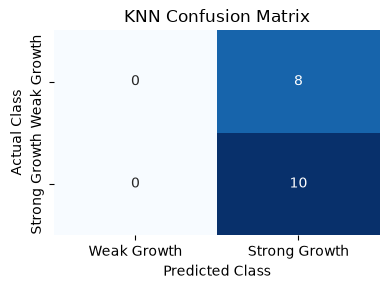

In [18]:
plt.figure(figsize=(4, 3))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Weak Growth",
        "Strong Growth"
    ],
    yticklabels=[
        "Weak Growth",
        "Strong Growth"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "KNN Confusion Matrix"
)

plt.tight_layout()
plt.show()

$$
\begin{bmatrix}
TN=0 & FP=8 \\
FN=0 & TP=10
\end{bmatrix}
$$

TN = Weak Growth correctly predicted as Weak\
FP = Weak Growth incorrectly predicted as Strong

FN = Strong Growth incorrectly predicted as Weak\
TP = Strong Growth correctly predicted as Strong

## Findinds: 
**KNN has collapsed into predicting every test observation as Strong Growth (Class 1)**

# Step 7. Add KNN to your model-comparison table

In [20]:
# ============================================================
# KNN RESULTS
# ============================================================

knn_results = pd.DataFrame({
    "Model": ["KNN"],
    "Accuracy": [knn_accuracy],
    "Balanced Accuracy": [knn_balanced_accuracy],
    "Precision": [knn_precision],
    "Recall": [knn_recall],
    "F1": [knn_f1],
    "ROC-AUC": [knn_roc_auc]
})

display(knn_results.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,KNN,0.5556,0.5,0.5556,1.0,0.7143,0.5


## Results: 

1. Despite having 55.56% accuracy, KNN has **no balanced ability to distinguish the two regimes**.

If we looked only at F1:
$$ 0.7143>0.500 (Logistic Regression) $$
we might incorrectly conclude:
"KNN is much better than Logistic Regression."
But the confusion matrix reveals why that conclusion would be misleading.

With \(K=5\), KNN predicted every holdout observation as Strong Growth. Although this produced 55.56% accuracy, **100% Strong-Growth recall**, and an F1 score of 0.7143, the model **failed to identify any Weak-Growth observations**. Balanced accuracy and ROC-AUC were both 0.50, indicating **no effective discrimination between the two PCE regimes**.

### Recommendations: 

In **hyperparameter tuning**, we can test different values of \(K\) using only the training period with time-series cross-validation. We can also investigate whether dimensionality reduction/feature selection improves KNN.

# if KNN = 2 ------------ (The result is almost same)

In [27]:
knn_pipeline_n = Pipeline([
    
    # Fill missing values using TRAINING medians
    ("imputer", SimpleImputer(strategy="median")),
    
    # KNN requires standardized features
    ("scaler", StandardScaler()),
    
    # Initial KNN model
    ("knn", KNeighborsClassifier(
        n_neighbors=2
    ))
])

In [28]:
knn_pipeline_n.fit(X_train,y_train)

knn_pred_n = knn_pipeline_n.predict(X_test)

knn_prob_n = knn_pipeline_n.predict_proba(X_test)[:, 1]


knn_predictions_n = pd.DataFrame({
    "Actual": y_test.squeeze(),
    "Predicted": knn_pred,
    "Probability_Strong": knn_prob
})
display(knn_predictions_n)

/usr/local/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,Actual,Predicted,Probability_Strong
Quarter,,,
2022-03-31,0,1,0.8
2022-06-30,1,1,0.8
2022-09-30,0,1,0.8
2022-12-31,0,1,0.8
2023-03-31,1,1,0.8
2023-06-30,0,1,0.8
2023-09-30,1,1,0.8
2023-12-31,1,1,0.8
2024-03-31,0,1,0.8


In [29]:
knn_accuracy_n = accuracy_score(
    y_test,
    knn_pred_n
)

knn_balanced_accuracy_n = balanced_accuracy_score(
    y_test,
    knn_pred_n
)

knn_precision_n = precision_score(
    y_test,
    knn_pred_n,
    zero_division=0
)

knn_recall_n = recall_score(
    y_test,
    knn_pred_n,
    zero_division=0
)

knn_f1_n = f1_score(
    y_test,
    knn_pred_n,
    zero_division=0
)

knn_roc_auc_n = roc_auc_score(
    y_test,
    knn_prob_n
)

In [26]:
knn_results_n = pd.DataFrame({
    "Model": ["KNN"],
    "Accuracy": [knn_accuracy_n],
    "Balanced Accuracy": [knn_balanced_accuracy_n],
    "Precision": [knn_precision_n],
    "Recall": [knn_recall_n],
    "F1": [knn_f1_n],
    "ROC-AUC": [knn_roc_auc_n]
})

display(knn_results_n.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,KNN,0.5556,0.5,0.5556,1.0,0.7143,0.4875


In [30]:
knn_cm_n = confusion_matrix(
    y_test,
    knn_pred_n
)

print("KNN Confusion Matrix:")
print(knn_cm_n)

KNN Confusion Matrix:
[[ 0  8]
 [ 0 10]]


| Metric            |    **KNN** | Interpretation                                               |
| ----------------- | ---------: | ------------------------------------------------------------ |
| Accuracy          | **0.5556** | 55.56% of test quarters were classified correctly            |
| Balanced Accuracy | **0.5000** | Average performance across Weak and Strong classes was 50.0% |
| Precision         | **0.5556** | When predicting Strong Growth, 55.56% were actually Strong   |
| Recall            | **1.0000** | It identified 100% of the actual Strong-Growth quarters      |
| F1                | **0.7143** | High F1 resulted from perfect Strong-Growth recall           |
| ROC-AUC           | **0.5000** | Probability ranking was equivalent to random discrimination  |


### interpretation: 

KNN predicted every test quarter as Strong Growth. Therefore, its high recall and F1 should not be interpreted as strong overall classification performance.